# Quick run: a CST model from STEP file to results

This notebook takes a model exported from CST Studio Suite as a STEP file, with its ports,
and computes its S- and Z-parameters, its resonances with their loaded and external Q,
and their figures of merit, with plots.

It runs as it is on an example: the C3794 cavity with its fundamental power coupler (FPC)
and its higher-order-mode (HOM) coupler, two cavities in a row. **For your own model,
export it from CST as a STEP file, change the settings in step 1, and run all cells.**

**Prerequisites**: the code installed ([Getting Started](../../getting_started.md)). The
example takes about 20 minutes and 9 GB of memory on a 16-core laptop.

## 1. Settings

Everything you change for your own model is in this cell.

In [1]:
from pathlib import Path

# The model: a STEP file exported from CST Studio Suite, with its ports
STEP_FILE = Path("../../example_models/c3794/c3794_4hc_1fpc_w_TEM.stp")
UNIT = "mm"            # the length unit the file was written in
N_REPEATS = 2          # identical copies in a row along z (1: the model alone)
CELLS = 1              # accelerating cells in one copy

# What each solid of the file is: metal ("PEC") or a material. * matches any ending.
MATERIALS = {"lh4*": "PEC", "dh2*": "PEC", "solid": "PEC",   # metal parts
             "ceramic*": {"eps_r": 10},                       # FPC window
             "solid1*": {"eps_r": 1}}                         # vacuum

FMIN, FMAX = 0.1, 1.0  # frequency band, GHz
NSAMPLES = 30          # full-order solves across the band
MAXH = 0.05            # largest element size, metres
PORT_MODES = {"port1": 5, "port2": 5, "default": 1}          # modes per port

| Setting | What to put |
|---|---|
| `STEP_FILE` | Your export: the model and its ports, which CST writes into the STEP file as faces named `port…` or `Ports\|…`. |
| `UNIT` | The unit of the CST project: `"mm"` (CST's default) or `"m"`. |
| `N_REPEATS` | Copies of the model joined in a row along $z$: the upper end of one copy joins the lower end of the next, through the ports that face each other. |
| `CELLS` | Accelerating cells in one copy. The accelerating gradient is taken over `N_REPEATS * CELLS` half wavelengths. |
| `MATERIALS` | The solid names printed in step 2.1. `"PEC"` removes a metal solid from the model; a dictionary (`eps_r`, `mu_r`, `sigma`, `tan_delta`) fills a solid with that material. |
| `FMIN`, `FMAX` | The band, in GHz. |
| `NSAMPLES` | Full-order solves spread over the band. The reduced model fills in between them; a band with many resonances needs more. |
| `MAXH` | About a tenth of the wavelength at `FMAX` for an accurate result (0.03 m at 1 GHz). The example uses 0.05 m, a quicker first look. |
| `PORT_MODES` | Modes per port, `"default"` for the ports not named. A port where copies join needs every mode that propagates in the band. |

## 2. Import the model

### 2.1 Read the STEP file

The project is written to `./simulations/quick_run`. `n=N_REPEATS` makes the model one part
used `N_REPEATS` times.

In [2]:
from cavsim3d import EMProject

proj = EMProject(name="quick_run", base_dir="./simulations", overwrite=True)
part = proj.import_geometry(STEP_FILE, name="model", unit=UNIT, n=N_REPEATS,
                            auto_build=False)

✅ Creating new project 'quick_run' at simulations\quick_run



STEP solids found:
  - lh4
  - dh2
  - ceramic
  - solid1
  - solid



Ports found: 4



Named 6 solids (5 unique materials):
  solid 0: 'lh4'
  solid 1: 'ceramic'
  solid 2: 'solid'
  solid 3: 'solid1'
  solid 4: 'dh2'
  solid 5: 'solid1'
Ports matched: 4/4
  port1                center=(-0.00000, 0.00000, 1.12200)  normal=(-0.0000, 0.0000, 1.0000)
  port2                center=(0.00000, 0.00000, -1.12860)  normal=(0.0000, 0.0000, -1.0000)
  port3                center=(0.00000, 0.20000, -0.46650)  normal=(-0.0000, 1.0000, 0.0000)
  port4                center=(-0.49479, -0.13525, -0.46650)  normal=(-0.9646, -0.2637, 0.0000)


The file's solids are listed by name: `MATERIALS` refers to these names. The ports come
from the file as well.

### 2.2 Assign the materials and mesh

In [3]:
part.set_materials(MATERIALS)
part.build()
proj.generate_mesh(maxh=MAXH, curvaturesafety=1.5)
# proj.geo.show()                  # 3D view of the model, ports in red

Subtracting 3 PEC solid(s): ['lh4', 'dh2', 'solid']


  Reassigned port4 to nearest non-PEC face (dist=0.0 mm)
Material properties assigned: 2 dielectric, 3 PEC


Named 6 solids (5 unique materials):
  solid 0: 'lh4'
  solid 1: 'ceramic'
  solid 2: 'solid'
  solid 3: 'solid1'
  solid 4: 'dh2'
  solid 5: 'solid1'
Ports matched: 4/4
  port1                center=(-0.00000, 0.00000, 1.12200)  normal=(-0.0000, 0.0000, 1.0000)
  port2                center=(0.00000, 0.00000, -1.12860)  normal=(0.0000, 0.0000, -1.0000)
  port3                center=(0.00000, 0.20000, -0.46650)  normal=(-0.0000, 1.0000, 0.0000)
  port4                center=(-0.49479, -0.13525, -0.46650)  normal=(-0.9646, -0.2637, 0.0000)
Subtracting 3 PEC solid(s): ['lh4', 'dh2', 'solid']
Main axis: Z (default). Parts follow the list order along +Z:
  1. model x2: z = [-1.129, 1.122] m
Mesh strategy: coupled (each unique part meshed and solved on its own, joined through port modes; repeated: model (n=2))


The metal solids are removed from the model, and the parts list shows the model used twice
along $z$.

## 3. Solve

### 3.1 Full-order solve

The model is solved at `NSAMPLES` frequencies. With repeated copies it is solved once;
the copies are joined afterwards.

In [4]:
proj.fds.solve(fmin=FMIN, fmax=FMAX, nsamples=NSAMPLES, order=2,
               nportmodes=PORT_MODES, solver_type="direct");

✅ Mesh strategy: coupled (repeated: model (n=2)): each unique part is solved on its own and the parts are joined through their port modes.


✅ Solve plan:
  model  geometry             compute   full-order solve, 30 samples



Structure Topology
  Type: Single structure
  Domains (2): ['ceramic', 'solid1']
  Ports (4): ['port1', 'port2', 'port3', 'port4']
  Mesh elements: 80933
✅ Section 'model': full-order solve


Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_11 (cos), kc=12.2744, sigma=+1
	port1 mode 1: TE_11 (sin), kc=12.2744, sigma=+1


	port1 mode 2: TM_01, kc=16.0320, sigma=+1
	port1 mode 3: TE_21 (cos), kc=20.3613, sigma=+1


	port1 mode 4: TE_21 (sin), kc=20.3613, sigma=+1


	port2 mode 0: TE_11 (cos), kc=12.2744, sigma=+1


	port2 mode 1: TE_11 (sin), kc=12.2744, sigma=+1


	port2 mode 2: TM_01, kc=16.0320, sigma=+1


	port2 mode 3: TE_21 (cos), kc=20.3613, sigma=+1


	port2 mode 4: TE_21 (sin), kc=20.3613, sigma=+1


	port3 mode 0: TEM_00, kc=0.0000, sigma=+1


	port4 mode 0: TEM_00, kc=0.0000, sigma=+1
Port eigenmodes complete: 12 total modes



FDS Solve: 0.1000 - 1.0000 GHz, 30 samples


Global Coupled Solve


  
Coupled solve complete: 4 external ports in 760.23s


✅ Netlist FOM stage complete: 1 unique section(s) for 2 instance(s)


### 3.2 Reduce, join and sweep

The full-order solutions are reduced to a small model, the copies of it are joined, and
the joined model is swept at 1001 frequencies.

In [5]:
if N_REPEATS == 1:
    model = proj.fds.fom.reduce(tol=1e-8)
else:
    model = proj.fds.foms.reduce(tol=1e-8).concatenate()
result = model.solve(fmin=FMIN, fmax=FMAX, nsamples=1001)

Model Order Reduction


Reduction complete: 558334 -> 171 DOFs (100.0% compression)



Concat Solve: 0.1 - 1.0 GHz, 1001 samples, system size 337


  Concat solve complete: 1.621s (1001 frequencies)


The 558,334 unknowns of the model reduce to 171. The joined model has 337, and its sweep
takes under two seconds.

## 4. S-parameters

### 4.1 Which port is which

In [6]:
if N_REPEATS == 1:
    proj.fds.print_port_map()
else:
    model.print_port_map()

port    part            its port  modes
port1   model_1         port2     5
port2   model_1         port3     1
port3   model_1         port4     1
port4   model_2         port1     5
port5   model_2         port3     1
port6   model_2         port4     1


The ports where the copies join are gone. The others are numbered copy by copy, in each
copy's own port order: here the lower beam-pipe end, the FPC and the HOM coupler of the
first copy, then the upper beam-pipe end, the FPC and the HOM coupler of the second.
Their port modes, as `port(mode)`:

In [7]:
from cavsim3d.analysis import plot_matrix, port_mode_labels

labels = port_mode_labels(model)
first = [i for i, label in enumerate(labels) if label.endswith("(1)")]
print(labels)

['1(1)', '1(2)', '1(3)', '1(4)', '1(5)', '2(1)', '3(1)', '4(1)', '4(2)', '4(3)', '4(4)', '4(5)', '5(1)', '6(1)']


### 4.2 The S-matrix

Between the first mode of every port, in dB. Entry $S_{i,j}$ is the response at port mode
$i$ to an excitation at port mode $j$.

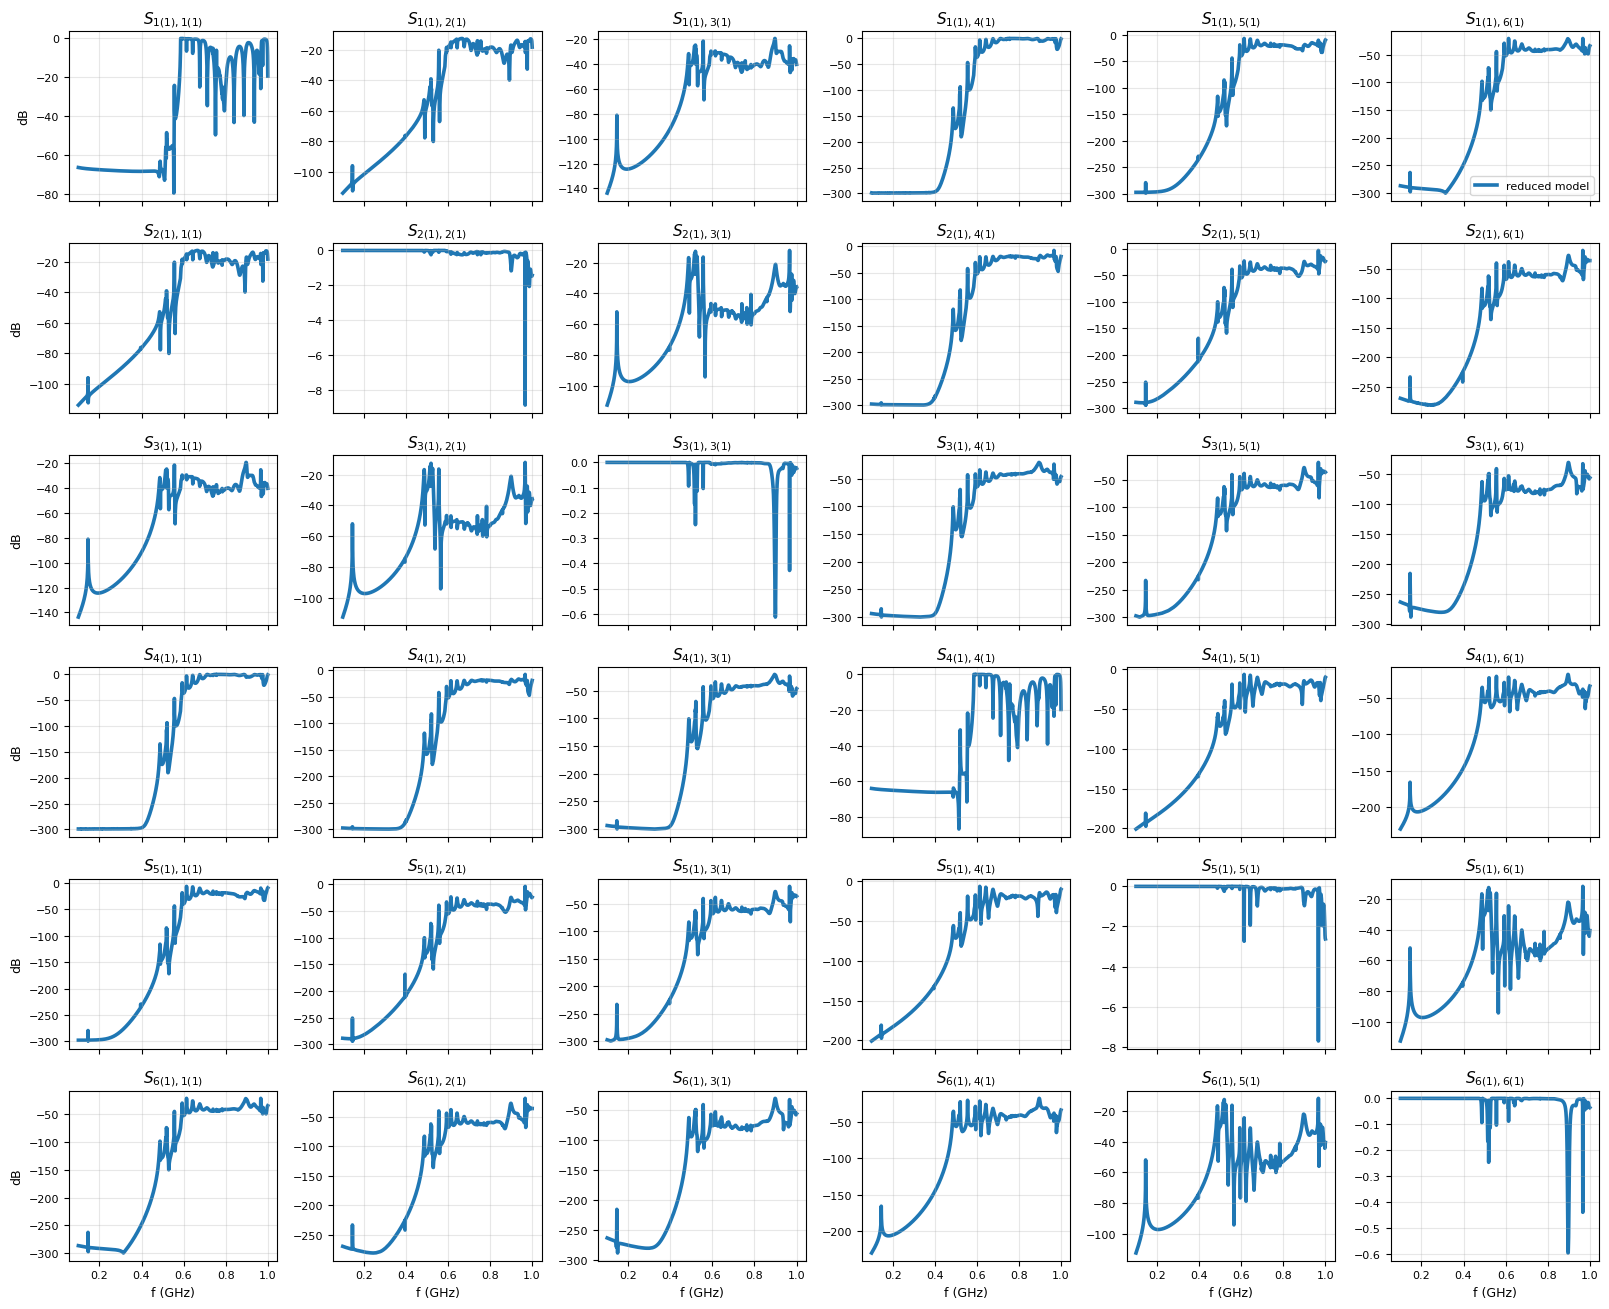

In [8]:
import matplotlib.pyplot as plt

fig, axs = plot_matrix({"reduced model": model}, ports=first, labels=labels, kind="S")
plt.show()

Well below the cutoff of the beam pipe's first mode (TE$_{11}$, 586 MHz) almost nothing
passes from one beam-pipe end to the other, and those entries fall to the numerical floor.

## 5. Z-parameters

The impedance matrix between the same port modes, as $20 \log_{10} |Z / 1\,\Omega|$.

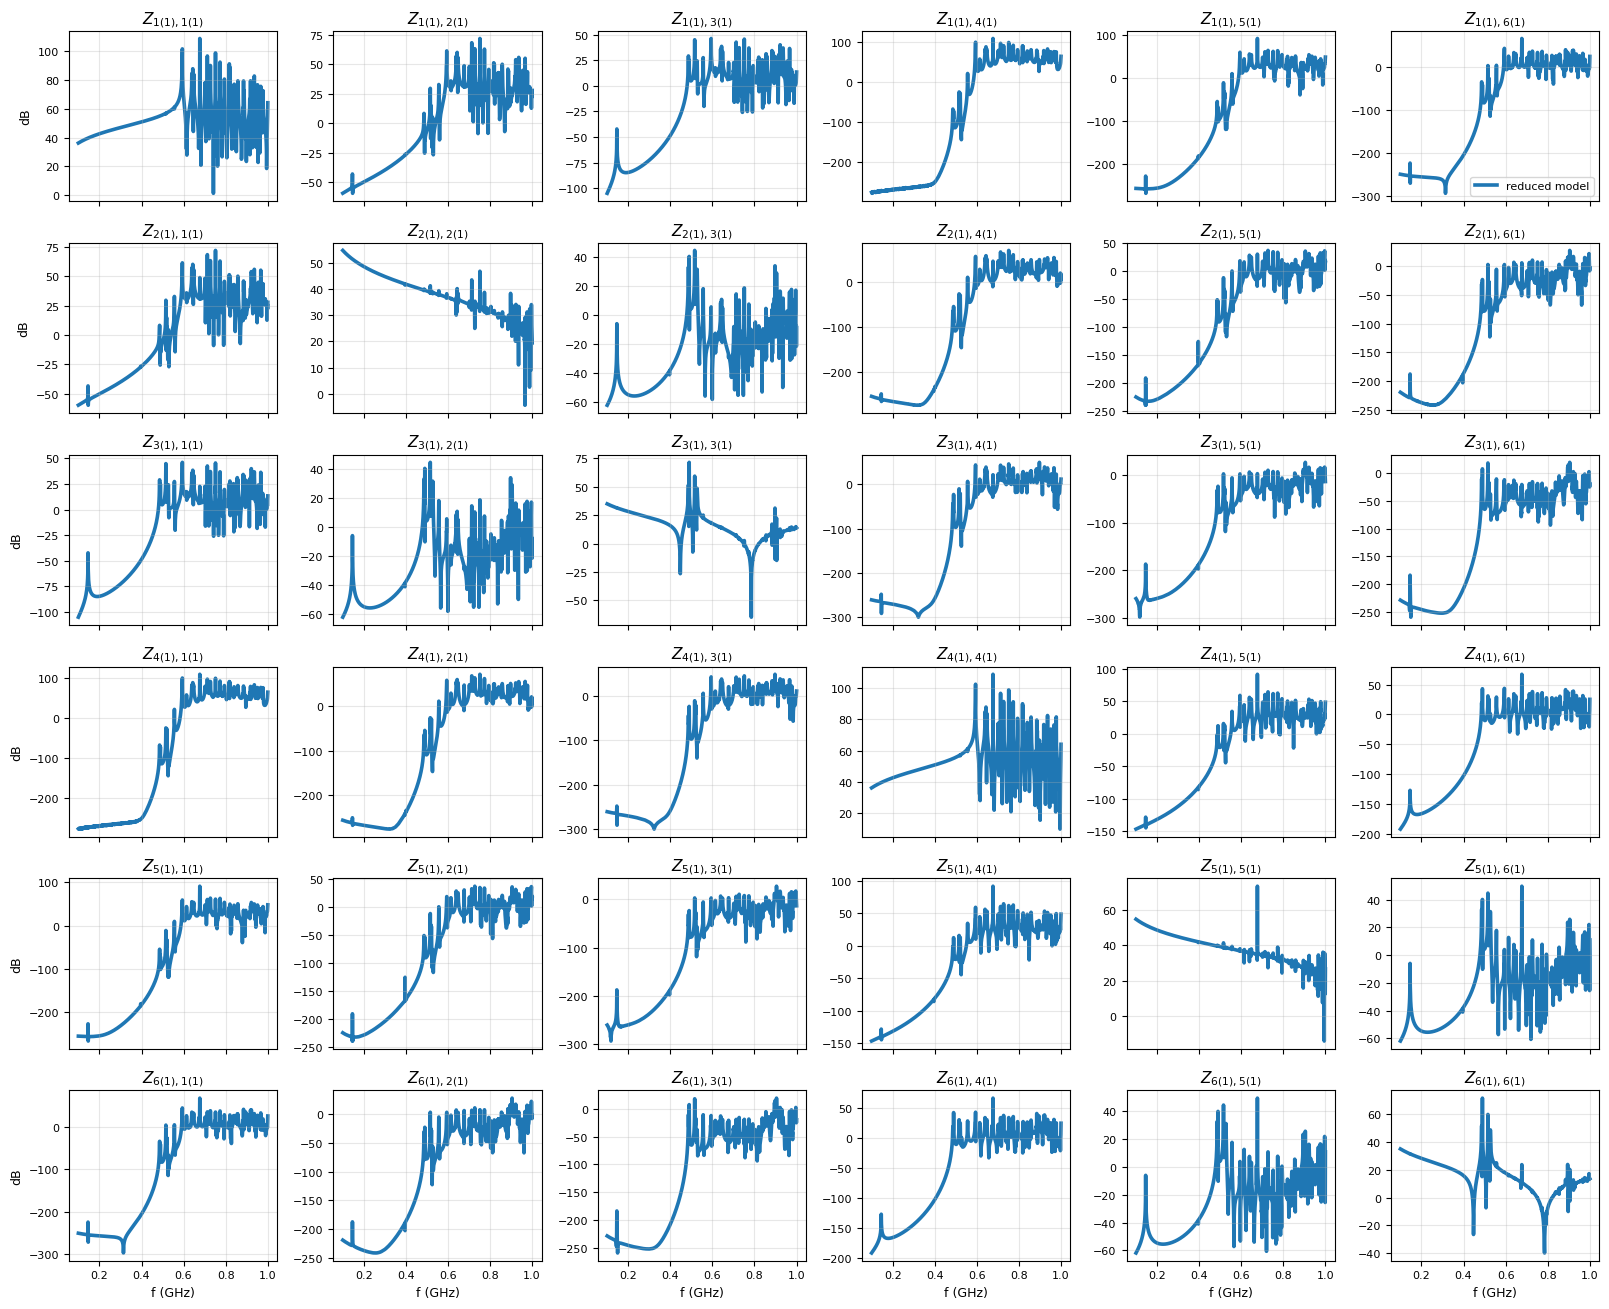

In [9]:
fig, axs = plot_matrix({"reduced model": model}, ports=first, labels=labels, kind="Z")
plt.show()

## 6. Resonances

### 6.1 Loaded and external Q

With every port terminated in its matched load, each resonance has a loaded Q, $Q_L$.
Its external Q at a port says how strongly that port damps it.

141 resonances between 0.1 and 1.0 GHz


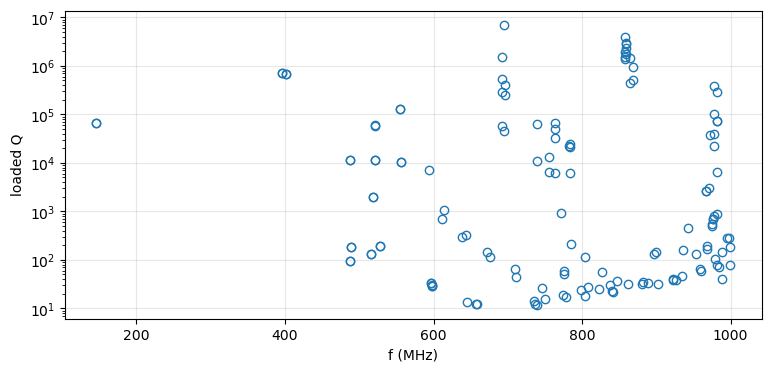

In [10]:
import numpy as np
import pandas as pd

q = model.get_external_q(fmin=FMIN, fmax=FMAX)
modes = pd.DataFrame({"f [MHz]": q["frequencies"] / 1e6, "Q_L": q["Q_L"]})
for port, qext in q["Qext"].items():
    modes[f"Qext {port}"] = qext
print(f"{len(modes)} resonances between {FMIN} and {FMAX} GHz")

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(modes["f [MHz]"], modes["Q_L"], "o", mfc="none")
ax.set_xlabel("f (MHz)")
ax.set_ylabel("loaded Q")
ax.grid(alpha=0.3)
plt.show()

### 6.2 R/Q and impedance of every resonance

$R/Q$ for a beam on the $z$ axis, and the impedance $R/Q \cdot Q_L$ it sees:

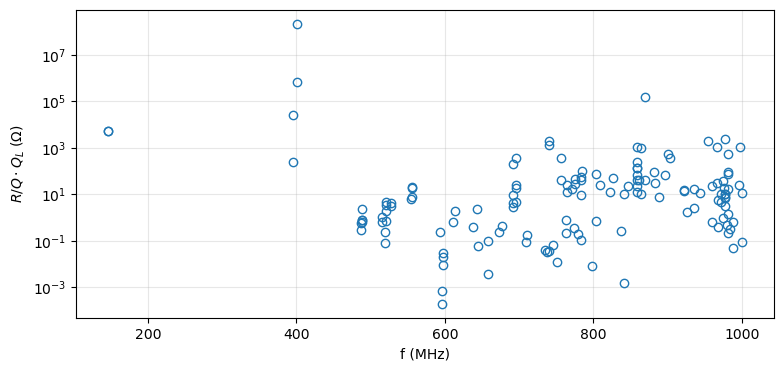

,f [MHz],Q_L,Qext port1,Qext port2,Qext port3,Qext port4,Qext port5,Qext port6,R/Q [Ohm],R/Q*Q_L [Ohm]
5,400.706625,692655.734288,inf,1.385204e+06,2.034813e+13,inf,1.385419e+06,2.035130e+13,304.380353,2.108308e+08
4,400.706625,692655.754957,inf,1.385413e+06,2.035120e+13,inf,1.385210e+06,2.034824e+13,0.994490,6.888395e+05
95,869.091657,944765.888504,2.761798e+06,2.501420e+07,2.441459e+07,1.762148e+06,3.924894e+07,4.449124e+07,0.163295,1.542754e+05
2,396.113049,699708.896716,inf,1.399546e+06,1.332831e+12,inf,1.399292e+06,1.332589e+12,0.036119,2.527275e+04
1,146.013491,66878.987960,inf,5.272795e+08,9.421128e+06,inf,3.837677e+06,6.856940e+04,0.076012,5.083622e+03
0,146.013491,66878.987948,inf,3.837688e+06,6.856961e+04,inf,5.270567e+08,9.417147e+06,0.075454,5.046316e+03
122,977.018730,378740.496319,1.144652e+06,3.601957e+07,1.741435e+08,1.052074e+06,1.291442e+06,1.195423e+08,0.006122,2.318602e+03
54,739.794428,63118.442345,2.649893e+05,5.513423e+05,2.864674e+08,1.605891e+05,2.490881e+05,9.496977e+07,0.030507,1.925531e+03
109,953.742321,129.607942,2.742741e+02,3.846884e+04,2.104153e+06,2.476770e+02,1.801830e+05,1.884640e+07,14.489352,1.877935e+03
55,739.827387,11149.427242,1.897844e+04,1.930724e+05,6.357968e+07,3.373005e+04,4.644540e+05,2.518609e+08,0.121675,1.356606e+03


In [11]:
modes["R/Q [Ohm]"] = [model.get_rq(int(i))["RQ"] for i in q["mode_index"]]
modes["R/Q*Q_L [Ohm]"] = modes["R/Q [Ohm]"] * modes["Q_L"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(modes["f [MHz]"], modes["R/Q*Q_L [Ohm]"], "o", mfc="none")
ax.set_xlabel("f (MHz)")
ax.set_ylabel(r"$R/Q \cdot Q_L$ ($\Omega$)")
ax.grid(alpha=0.3)
plt.show()

modes.sort_values("R/Q*Q_L [Ohm]", ascending=False).head(10)

The accelerating mode leads, at 400.707 MHz with $R/Q$ = 304 Ω. The two FPCs set its
loaded Q ($Q_{ext}$ = 1.39 × 10⁶ each); the HOM couplers hardly load it
($Q_{ext}$ = 2 × 10¹³). The next mode, at the same frequency, has $R/Q$ ≈ 1 Ω: in it the
voltages of the two cavities cancel. Of the higher-order modes, the one at 869.09 MHz
stands out, with $Q_L$ = 9.4 × 10⁵ and $R/Q \cdot Q_L$ = 1.5 × 10⁵ Ω.

Dipole modes have no field on the axis; their $R/Q$ needs an offset from it
(`model.get_rq(i, offset=(x, y))`).

### 6.3 Figures of merit of the accelerating mode

The mode with the largest $R/Q$, with the gradient taken over `N_REPEATS * CELLS` half
wavelengths:

In [12]:
k = int(np.argmax(modes["R/Q [Ohm]"]))
f0 = q["frequencies"][k]
n_cells = N_REPEATS * CELLS
fm = model.get_figures_of_merit(int(q["mode_index"][k]), n_cells=n_cells,
                                active_length=n_cells * 299792458.0 / (2 * f0))
pd.Series(fm).round(4)

freq [MHz]              400.7071
Q []                  37941.3797
Vacc [MV]                 0.8754
Eacc [MV/m]               1.1701
Epk [MV/m]                1.3039
Hpk [A/m]              9119.9906
Bpk [mT]                 11.4605
ff [%]                   99.4863
Rsh [MOhm]               11.5486
R/Q [Ohm]               304.3804
Epk/Eacc []               1.1144
Bpk/Eacc [mT/MV/m]        9.7946
G [Ohm]                 195.4715
GR/Q [Ohm^2]          59497.6752
U [J]                     1.0000
Ploss [W]             66358.0769
k_loss [V/pC]             0.1916
Vt [MV]                   0.0024
Et [MV/m]                 0.0032
R/Q_t [Ohm]               0.0023
k_kick [V/pC/m]           0.0000
Rs [Ohm]                  0.0052
Active Length [mm]      748.1595
N Cells                   2.0000
U_frac_ceramic []         0.0000
Epk_ceramic [MV/m]        0.0001
U_frac_solid1 []          1.0000
Epk_solid1 [MV/m]         1.3031
dtype: float64

`Q` is the unloaded Q, with copper walls: `conductivity=` or `surface_resistance=` sets
other walls. Peak surface fields converge slowly with the mesh, and on this coarse one
`Epk/Eacc` comes out at 1.11: check `Epk` and `Bpk` with a smaller `MAXH` before relying
on them.

## 7. The results you have

In the notebook:

| Result | Get it with | Format |
|---|---|---|
| S and Z | `result["S"]`, `result["Z"]`, `result["frequencies"]` | complex arrays `[frequency, response, excitation]`; frequencies in Hz, Z in ohm |
| One entry | `model.S_dict["1(1)2(1)"]` | the entry keyed excitation, then response |
| Chosen port modes | `cavsim3d.analysis.network_matrix(model, labels)` | array, as above |
| Which port is which | `model.port_map()` | list of dictionaries |
| Resonances (ports closed) | `model.get_resonant_frequencies()` | Hz |
| Loaded and external Q | `model.get_external_q(fmin, fmax)` | dictionary of arrays; `mode_index` numbers the modes for the calls below |
| R/Q of a mode | `model.get_rq(i)` | dictionary: `RQ` [ohm], `V` [V], `U` [J] |
| Figures of merit of a mode | `model.get_figures_of_merit(i)` | dictionary; each key carries its unit |
| Field of a mode | `model.reconstruct_chain_eigenmode(i)` (copies joined), `model.get_eigenmode(i)` (`N_REPEATS = 1`) | `(field, mesh, label)` for `cavsim3d.utils.visualization.draw(field, mesh)`; `(frequency, field)` |
| The tables above | `modes`, `pd.Series(fm)` | pandas; `modes.to_csv("modes.csv")` writes a file |

On disk, every stage has saved itself in the project folder:

In [13]:
for path in sorted(proj.project_path.rglob("*")):
    if path.is_file():
        size = path.stat().st_size / 1e6
        print(f"{path.relative_to(proj.project_path).as_posix():50s} {size:9.1f} MB")

fds/config.json                                          0.0 MB
fds/foms/matrices/B_model.h5                            53.6 MB
fds/foms/matrices/K_model.h5                           277.2 MB
fds/foms/matrices/M_model.h5                           277.2 MB
fds/foms/roms/concat/matrices/A.h5                       1.8 MB
fds/foms/roms/concat/matrices/B.h5                       0.1 MB
fds/foms/roms/concat/matrices/W.h5                       1.8 MB
fds/foms/roms/concat/metadata.json                       0.0 MB
fds/foms/roms/concat/s/s.h5                              3.1 MB
fds/foms/roms/concat/snapshots/snapshots.h5             75.6 MB
fds/foms/roms/concat/z/z.h5                              3.1 MB
fds/foms/roms/matrices/A_r_model.h5                      0.2 MB
fds/foms/roms/matrices/B_r_model.h5                      0.0 MB
fds/foms/roms/matrices/Q_L_inv_model.h5                  0.2 MB
fds/foms/roms/matrices/W_model.h5                      763.8 MB
fds/foms/roms/structures.json           

| Folder | Holds | Format |
|---|---|---|
| `geometry/` | the imported STEP file | STEP |
| `mesh/` | the mesh and the finite element space of the model | pickle |
| `fds/foms/matrices/` | the full-order system matrices | HDF5 |
| `fds/foms/s/`, `z/`, `snapshots/` | full-order S and Z, and the solutions at each sample | HDF5 |
| `fds/foms/roms/` | the reduced model | HDF5 |
| `fds/foms/roms/concat/` | the joined model: its matrices, and its sweep (`s/`, `z/`, `snapshots/`) | HDF5 |

The file names end in the part's name (`model`). To come back to the results later,
reopen the project: `proj = EMProject(name="quick_run", base_dir="./simulations")`;
`proj.fds.foms.roms.concat` is the joined model, loaded from disk. See
[Results](../../reference/results.md) and [Project folder](../../reference/project_folder.md)
for every entry.

## What we did

- Read a STEP file exported from CST, with its ports, and assigned its materials.
- Solved the model at full order, reduced it, and joined copies of it.
- Plotted its S- and Z-parameters, listed its resonances with their loaded and external
  Q, R/Q and impedance, and computed the figures of merit of the accelerating mode.

**Next:** [Your first simulation](../basics/first_simulation.ipynb) takes each step
slowly, on a waveguide with a known answer.

**Background:** [How a model is solved in pieces](../../explanation/architecture.md).